# Cell-cycle phase visualization for burst kinetics txburst

This notebook loads GM12878 txburst results for **G1**, **S**, and **G2M**, computes four burst-kinetic quantities, and visualizes only:

- `bf`
- `bs`

Outputs are saved under `results/cellcycle_burst_visualization/`.


In [20]:
# ================================
# 0. Imports and plotting style
# ================================
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.colors as mcolors

import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault

rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 6 ,
        'axes.titleweight' :'regular',
        
        'figure.titleweight' : 'regular' ,
        'figure.titlesize' : 6 ,
        'figure.labelsize' : 6 ,
        'figure.labelweight' : 'regular' , 
        
        'axes.labelsize' : 6 ,
        'axes.labelpad' : 2 ,
        'axes.labelweight' : 'regular' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'legend.fontsize' : 6 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'black',   
        'legend.edgecolor': 'black',
        'legend.labelcolor': 'black',  # 设置图例标签字体颜色（在新版matplotlib中支持）
        'axes.edgecolor': 'black',
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'axes.titlecolor': 'black',
        'axes.labelcolor': 'black',

        'xtick.labelsize': 6,
        'ytick.labelsize': 6,
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        'xtick.major.width': 0.5,  # X轴刻度主刻度线宽度
        'ytick.major.width': 0.5, 
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        'text.color': 'black',  # 全局文字颜色

        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )


# COLOR_MAP = {'H3K4me1':'#A28F19','H3K4me3':'#7FA5D0','H3K9me3':'#FDE4A4','H3K27ac':'#F5B6AC','H3K27me3':'#7CA68B','H3K36me3':'#80448A','H3K9ac':'#C7886D'}
COLOR_MAP = {'H3K4me1':'#BB72AC','H3K4me3':'#56B4E6','H3K9me3':'#7CC9C1','H3K27ac':'#EC6D5D','H3K27me3':'#F4DE28','H3K36me3':'#88C463','H3K9ac':'#3D60AC'}

COLORS = ['#39729C', "#D8B66F"]



## Origin

### label consistency

In [21]:
import pandas as pd
from functools import reduce
from pathlib import Path

# extra/datasets/processed/v2/meta_datasets/meta_data_E116_deeptx_delay_0.5_with_cellsize_1_cellcycle_{TARGET_PHASE}_{PHASE_ORIGIN}.csv

BASE_DIR = Path("extra/datasets/processed/v2/meta_datasets")
PARSE_ORIGIN = 'origin'
BURST_METHOD = 'deeptx'
FILES = {
    "all": BASE_DIR / "meta_data_E116_deeptx.csv",
    "G1": BASE_DIR / f"meta_data_E116_deeptx_delay_0.5_with_cellsize_1_cellcycle_G1_{PARSE_ORIGIN}.csv",
    "S": BASE_DIR / f"meta_data_E116_deeptx_delay_0.5_with_cellsize_1_cellcycle_S_{PARSE_ORIGIN}.csv",
    "G2M": BASE_DIR / f"meta_data_E116_deeptx_delay_0.5_with_cellsize_1_cellcycle_G2M_{PARSE_ORIGIN}.csv",
}

KEEP_COLS = [
    "gene_id",
    "bs", "bf",
    "bs_label", "bf_label",
]


def load_and_rename(path, tag, keep_cols=KEEP_COLS):
    """
    Read one metadata file and add suffix to value columns.

    Example:
        bs -> bs_G1
        bf_label -> bf_label_G1
    """
    df = pd.read_csv(path)

    missing = [c for c in keep_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing columns: {missing}")

    df = df[keep_cols].copy()

    # 防止 gene_id 重复导致 merge 后行数膨胀
    if df["gene_id"].duplicated().any():
        n_dup = int(df["gene_id"].duplicated().sum())
        print(f"[Warning] {tag}: duplicated gene_id rows = {n_dup}. Keeping first.")
        df = df.drop_duplicates(subset="gene_id", keep="first")

    rename_map = {
        c: f"{c}_{tag}"
        for c in df.columns
        if c != "gene_id"
    }

    df = df.rename(columns=rename_map)

    return df


dfs = [
    load_and_rename(path, tag)
    for tag, path in FILES.items()
]

meta_data_merge = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on="gene_id",
        how="inner",
        validate="one_to_one",
    ),
    dfs,
)

print(meta_data_merge.shape)
print(meta_data_merge.head())



(15420, 17)
           gene_id    bs_all    bf_all  bs_label_all  bf_label_all     bs_G1  \
0  ENSG00000143320  1.165584  0.001020             1             0  1.111244   
1  ENSG00000143319  3.580069  0.317895             1             1  1.433335   
2  ENSG00000143318  0.404731  0.003868             0             0  0.280396   
3  ENSG00000143315  0.311112  0.261071             0             1  0.032784   
4  ENSG00000143303  1.375229  0.170838             1             1  0.424480   

      bf_G1  bs_label_G1  bf_label_G1       bs_S      bf_S  bs_label_S  \
0  0.001437            1            0   0.395767  0.000666           0   
1  0.353603            1            1   2.940012  0.758957           1   
2  0.004950            0            0   0.223645  0.004522           0   
3  0.232420            0            1  12.013654  0.029264           1   
4  0.300130            0            1   7.027372  0.057816           1   

   bf_label_S    bs_G2M    bf_G2M  bs_label_G2M  bf_label_G2M 

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_10114/2948991850.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, rotation=0)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_10114/2948991850.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, rotation=0)


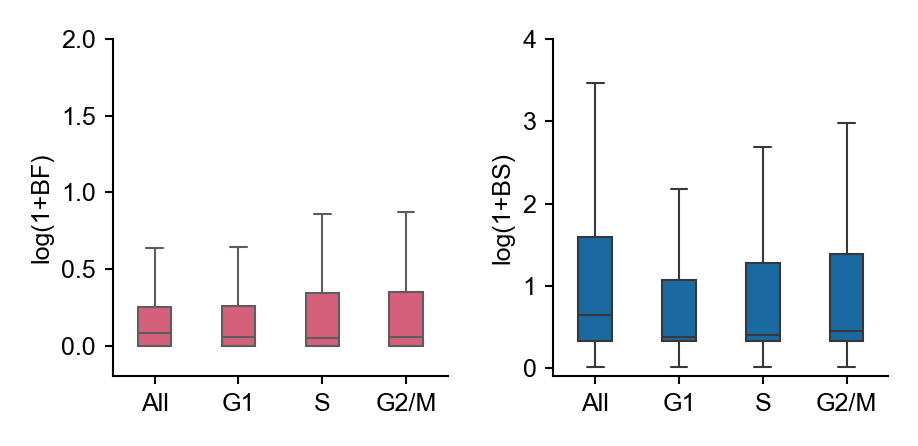

In [22]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

PHASES = ["all", "G1", "S", "G2M"]
METRICS = ["bf", "bs"]
palette = ['#E94C72','#036EB8']
def make_long_df(df, metric, phases=PHASES):
    plot_df = pd.DataFrame({
        "phase": np.repeat(phases, len(df)),
        "value": np.concatenate([
            np.log1p(df[f"{metric}_{phase}"].values)
            for phase in phases
        ])
    })
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()
    return plot_df

fig, axes = plt.subplots(
    1, 2,
    figsize=(8 / 2.54, 4 / 2.54),
    sharey=False
)

for ax, metric in zip(axes, METRICS):
    plot_df = make_long_df(meta_data_merge, metric)
    color = palette[0] if metric == 'bf' else palette[1]
    sns.boxplot(
        data=plot_df,
        x="phase",
        y="value",
        order=PHASES,
        width=0.4,
        fliersize=0,
        linewidth=0.5,
        color=color,
        ax=ax,
    )

    if metric == 'bf':
        ax.set_ylim(-0.2, top=2)
    if metric == 'bs':
        ax.set_ylim(-0.1, top=4)

    ax.set_xlabel("")
    ax.set_ylabel(f"log(1+{metric.upper()})")
    xticklabels = ['All', 'G1', 'S', 'G2/M', ]
    ax.set_xticklabels(xticklabels, rotation=0)
    # ax.set_title(f"{metric}")

    # sns.despine(ax=ax)

# fig.suptitle("Burst kinetic metrics across G1, S, G2M, and all cells", y=0.95)
plt.tight_layout()
plt.savefig(f"benchmarks/revised_v2/reviewer4/figures/cellcycle_burst_metrics_boxplot_{PARSE_ORIGIN}_{BURST_METHOD}.eps", format='eps', bbox_inches='tight')
plt.show()

### compute bs bf label consistencies

In [23]:
import numpy as np
import matplotlib.colors as mcolors


phases = ["all","G1", "S", "G2M"]
consistency_matrix = np.zeros((len(phases), len(phases), 4))  # 2 for bf and bs
for idx, indicator in enumerate(["bf", "bs",]):
    for i, phase1 in enumerate(phases):
        for j, phase2 in enumerate(phases):
            consistency = meta_data_merge[meta_data_merge[f"{indicator}_label_{phase1}"] == meta_data_merge[f"{indicator}_label_{phase2}"]].shape[0] / meta_data_merge.shape[0]
            consistency_matrix[i, j, idx] = consistency




In [24]:
meta_data_merge

,gene_id,bs_all,bf_all,bs_label_all,bf_label_all,bs_G1,bf_G1,bs_label_G1,bf_label_G1,bs_S,bf_S,bs_label_S,bf_label_S,bs_G2M,bf_G2M,bs_label_G2M,bf_label_G2M
0,ENSG00000143320,1.165584,0.001020,1,0,1.111244,0.001437,1,0,0.395767,0.000666,0,0,0.064423,0.003223,0,0
1,ENSG00000143319,3.580069,0.317895,1,1,1.433335,0.353603,1,1,2.940012,0.758957,1,1,3.313069,0.585305,1,1
2,ENSG00000143318,0.404731,0.003868,0,0,0.280396,0.004950,0,0,0.223645,0.004522,0,0,0.061723,0.003933,0,0
3,ENSG00000143315,0.311112,0.261071,0,1,0.032784,0.232420,0,1,12.013654,0.029264,1,0,0.320767,0.337366,0,1
4,ENSG00000143303,1.375229,0.170838,1,1,0.424480,0.300130,0,1,7.027372,0.057816,1,1,1.498843,0.232422,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15415,ENSG00000012817,0.395880,0.000666,0,0,0.395754,0.000666,0,0,0.395739,0.000666,0,0,0.395846,0.000666,0,0
15416,ENSG00000187191,0.395868,0.000666,0,0,0.395962,0.000666,0,0,0.395879,0.000666,0,0,0.395771,0.000666,0,0
15417,ENSG00000178605,5.570511,0.366207,1,1,1.641754,0.623638,1,1,6.111833,0.570078,1,1,8.591413,0.411861,1,1
15418,ENSG00000198692,0.395820,0.000666,0,0,0.395958,0.000666,0,0,0.395798,0.000666,0,0,0.395887,0.000666,0,0


### plot heatmap

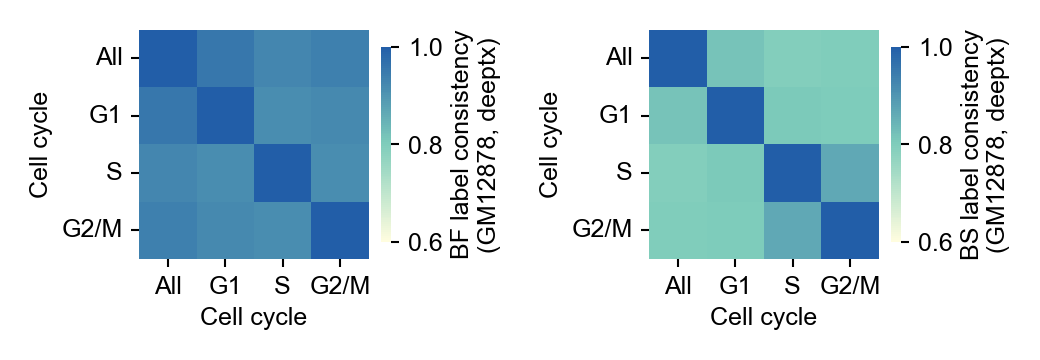

In [25]:
COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]

fig, ax = plt.subplots(1,2, figsize=(9/2.54, 4/2.54))

for idx, indicator in enumerate(["bf", "bs",]):
    vmin = 0.6 if indicator == 'bf' else 0.6
    sns.heatmap(consistency_matrix[:,:,idx],cbar_kws={"shrink": 0.6, "fraction": 0.05},vmin=vmin, vmax=1,cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100), ax=ax[idx])

    ticklabels = ['All', 'G1', 'S', 'G2/M', ]
    ax[idx].set_xticklabels(ticklabels,rotation=0)
    ax[idx].set_yticklabels(ticklabels,rotation=0)
    ax[idx].set_aspect('equal')
    ax[idx].tick_params(axis='both',width=0.5)  # 修改刻度标签字体大小
    ax[idx].set_xlabel('Cell cycle', fontsize=6)
    ax[idx].set_ylabel('Cell cycle', fontsize=6)
    cbar = ax[idx].collections[0].colorbar
    # 调整colorbar的刻度粗细
        # 控制 tick label 显示格式
    cbar_ticks = np.linspace(vmin, 1, 3)  
    cbar.set_ticks(cbar_ticks)
    cbar.set_ticklabels([f"{x:.1f}" for x in cbar_ticks])
    cbar.ax.tick_params(width=0.5,)  # 设置colorbar刻度的粗细
    cbar.set_label(f'{indicator.upper()} label consistency\n(GM12878, {BURST_METHOD})',fontsize=6)

plt.tight_layout()
plt.savefig(f"benchmarks/revised_v2/reviewer4/figures/cellcycle_label_consistency_{PARSE_ORIGIN}_{BURST_METHOD}.eps", format='eps', bbox_inches='tight')
plt.show()

In [26]:
consistency_matrix[:,:,0]

array([[1.        , 0.95486381, 0.92503243, 0.93644617],
       [0.95486381, 1.        , 0.9151751 , 0.92127108],
       [0.92503243, 0.9151751 , 1.        , 0.91245136],
       [0.93644617, 0.92127108, 0.91245136, 1.        ]])

## Deepcycle

### label consistency

In [27]:
import pandas as pd
from functools import reduce
from pathlib import Path

BASE_DIR = Path("extra/datasets/processed/v2/meta_datasets")
PARSE_ORIGIN = 'deepcycle'
BURST_METHOD = 'deeptx'
FILES = {
    "all": BASE_DIR / "meta_data_E116_deeptx.csv",
    "G1": BASE_DIR / f"meta_data_E116_deeptx_delay_0.5_with_cellsize_1_cellcycle_G1_{PARSE_ORIGIN}.csv",
    "S": BASE_DIR / f"meta_data_E116_deeptx_delay_0.5_with_cellsize_1_cellcycle_S_{PARSE_ORIGIN}.csv",
    "G2M": BASE_DIR / f"meta_data_E116_deeptx_delay_0.5_with_cellsize_1_cellcycle_G2M_{PARSE_ORIGIN}.csv",
}

KEEP_COLS = [
    "gene_id",
    "bs", "bf",
    "bs_label", "bf_label",
]


def load_and_rename(path, tag, keep_cols=KEEP_COLS):
    """
    Read one metadata file and add suffix to value columns.

    Example:
        bs -> bs_G1
        bf_label -> bf_label_G1
    """
    df = pd.read_csv(path)

    missing = [c for c in keep_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing columns: {missing}")

    df = df[keep_cols].copy()

    # 防止 gene_id 重复导致 merge 后行数膨胀
    if df["gene_id"].duplicated().any():
        n_dup = int(df["gene_id"].duplicated().sum())
        print(f"[Warning] {tag}: duplicated gene_id rows = {n_dup}. Keeping first.")
        df = df.drop_duplicates(subset="gene_id", keep="first")

    rename_map = {
        c: f"{c}_{tag}"
        for c in df.columns
        if c != "gene_id"
    }

    df = df.rename(columns=rename_map)

    return df


dfs = [
    load_and_rename(path, tag)
    for tag, path in FILES.items()
]

meta_data_merge = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on="gene_id",
        how="inner",
        validate="one_to_one",
    ),
    dfs,
)

print(meta_data_merge.shape)
print(meta_data_merge.head())



(15420, 17)
           gene_id    bs_all    bf_all  bs_label_all  bf_label_all      bs_G1  \
0  ENSG00000143320  1.165584  0.001020             1             0   0.395820   
1  ENSG00000143319  3.580069  0.317895             1             1  13.438850   
2  ENSG00000143318  0.404731  0.003868             0             0   0.698166   
3  ENSG00000143315  0.311112  0.261071             0             1   0.425985   
4  ENSG00000143303  1.375229  0.170838             1             1  17.963346   

      bf_G1  bs_label_G1  bf_label_G1      bs_S      bf_S  bs_label_S  \
0  0.000666            0            0  0.492826  0.001227           0   
1  0.233340            1            1  2.128736  0.443865           1   
2  0.002463            1            0  0.567919  0.005466           0   
3  0.257686            0            1  0.320386  0.249059           0   
4  0.025328            1            0  1.040973  0.197032           1   

   bf_label_S    bs_G2M    bf_G2M  bs_label_G2M  bf_label_G2M 

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_10114/1427804858.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, rotation=0)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_10114/1427804858.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, rotation=0)


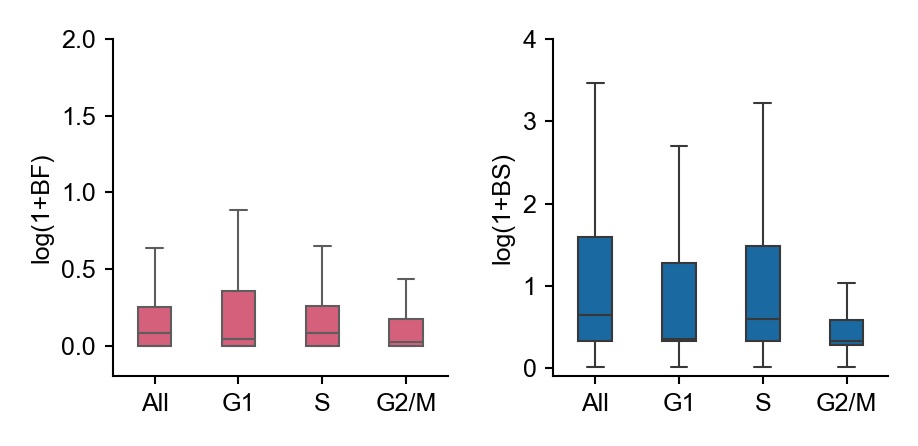

In [28]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

PHASES = ["all", "G1", "S", "G2M"]
METRICS = ["bf", "bs"]
palette = ['#E94C72','#036EB8']
def make_long_df(df, metric, phases=PHASES):
    plot_df = pd.DataFrame({
        "phase": np.repeat(phases, len(df)),
        "value": np.concatenate([
            np.log1p(df[f"{metric}_{phase}"].values)
            for phase in phases
        ])
    })
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()
    return plot_df

fig, axes = plt.subplots(
    1, 2,
    figsize=(8 / 2.54, 4 / 2.54),
    sharey=False
)

for ax, metric in zip(axes, METRICS):
    plot_df = make_long_df(meta_data_merge, metric)
    color = palette[0] if metric == 'bf' else palette[1]
    sns.boxplot(
        data=plot_df,
        x="phase",
        y="value",
        order=PHASES,
        width=0.4,
        fliersize=0,
        linewidth=0.5,
        color=color,
        ax=ax,
    )

    if metric == 'bf':
        ax.set_ylim(-0.2, top=2)
    if metric == 'bs':
        ax.set_ylim(-0.1, top=4)

    ax.set_xlabel("")
    ax.set_ylabel(f"log(1+{metric.upper()})")
    xticklabels = ['All', 'G1', 'S', 'G2/M', ]
    ax.set_xticklabels(xticklabels, rotation=0)
    # ax.set_title(f"{metric}")

    # sns.despine(ax=ax)

# fig.suptitle("Burst kinetic metrics across G1, S, G2M, and all cells", y=0.95)
plt.tight_layout()
plt.savefig(f"benchmarks/revised_v2/reviewer4/figures/cellcycle_burst_metrics_boxplot_{PARSE_ORIGIN}_{BURST_METHOD}.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [29]:
meta_data_merge[['bs_all', 'bs_G1', 'bs_S', 'bs_G2M']].describe()

,bs_all,bs_G1,bs_S,bs_G2M
count,15420.000000,15420.000000,15420.000000,15420.000000
mean,8.365534,11.281113,7.826776,5.245930
std,31.977253,484.287223,30.477271,30.207001
min,0.014295,0.015481,0.017782,0.013834
25%,0.395805,0.395787,0.395800,0.325195
50%,0.907575,0.427346,0.816196,0.395820
75%,3.899610,2.594114,3.435545,0.790895
max,1225.342711,59999.999260,1555.052688,738.360606


### compute bs bf label consistencies

In [30]:
import numpy as np
import matplotlib.colors as mcolors


phases = ["all","G1", "S", "G2M"]
consistency_matrix = np.zeros((len(phases), len(phases), 4))  # 2 for bf and bs
for idx, indicator in enumerate(["bf", "bs",]):
    for i, phase1 in enumerate(phases):
        for j, phase2 in enumerate(phases):
            consistency = meta_data_merge[meta_data_merge[f"{indicator}_label_{phase1}"] == meta_data_merge[f"{indicator}_label_{phase2}"]].shape[0] / meta_data_merge.shape[0]
            consistency_matrix[i, j, idx] = consistency




### plot heatmap

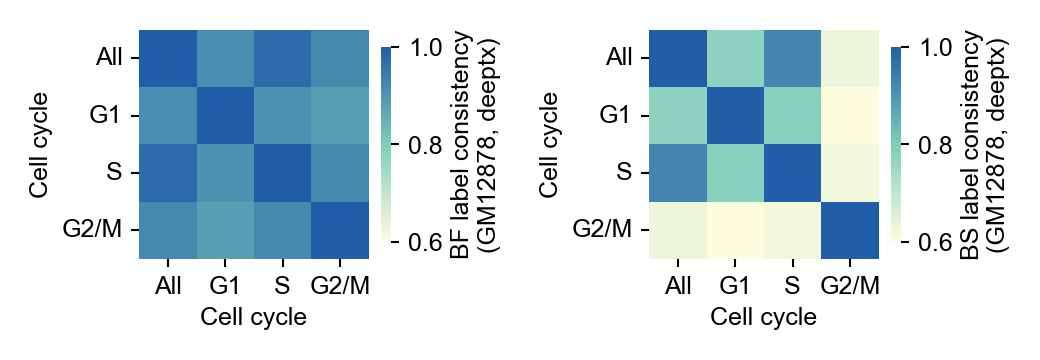

In [31]:
COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]

fig, ax = plt.subplots(1,2, figsize=(9/2.54, 4/2.54))

for idx, indicator in enumerate(["bf", "bs",]):
    vmin = 0.6 if indicator == 'bf' else 0.6
    sns.heatmap(consistency_matrix[:,:,idx],cbar_kws={"shrink": 0.6, "fraction": 0.05},vmin=vmin, vmax=1,cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100), ax=ax[idx])

    ticklabels = ['All', 'G1', 'S', 'G2/M', ]
    ax[idx].set_xticklabels(ticklabels,rotation=0)
    ax[idx].set_yticklabels(ticklabels,rotation=0)
    ax[idx].set_aspect('equal')
    ax[idx].tick_params(axis='both',width=0.5)  # 修改刻度标签字体大小
    ax[idx].set_xlabel('Cell cycle', fontsize=6)
    ax[idx].set_ylabel('Cell cycle', fontsize=6)
    cbar = ax[idx].collections[0].colorbar
    # 调整colorbar的刻度粗细
    cbar.ax.tick_params(width=0.5,)  # 设置colorbar刻度的粗细
    cbar.set_label(f'{indicator.upper()} label consistency\n(GM12878, {BURST_METHOD})',fontsize=6)

plt.tight_layout()
plt.savefig(f"benchmarks/revised_v2/reviewer4/figures/cellcycle_label_consistency_{PARSE_ORIGIN}_{BURST_METHOD}.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [32]:
consistency_matrix

array([[[1.        , 1.        , 0.        , 0.        ],
        [0.91245136, 0.77885863, 0.        , 0.        ],
        [0.97367056, 0.92607004, 0.        , 0.        ],
        [0.92178988, 0.62827497, 0.        , 0.        ]],

       [[0.91245136, 0.77885863, 0.        , 0.        ],
        [1.        , 1.        , 0.        , 0.        ],
        [0.90661479, 0.7849546 , 0.        , 0.        ],
        [0.8845655 , 0.59922179, 0.        , 0.        ]],

       [[0.97367056, 0.92607004, 0.        , 0.        ],
        [0.90661479, 0.7849546 , 0.        , 0.        ],
        [1.        , 1.        , 0.        , 0.        ],
        [0.92127108, 0.6232166 , 0.        , 0.        ]],

       [[0.92178988, 0.62827497, 0.        , 0.        ],
        [0.8845655 , 0.59922179, 0.        , 0.        ],
        [0.92127108, 0.6232166 , 0.        , 0.        ],
        [1.        , 1.        , 0.        , 0.        ]]])